<a href="https://colab.research.google.com/github/htutmyatoo/topic-lens-ai/blob/main/TopicLens_AI_Model_Development.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TopicLens AI: Twitter Topic Classification

This notebook is to investigate the best model to classify tweets into 6 topic categories using an NLP pipeline by ensuring CRISP-DM methodology.

**Student Information:**
- Student Registration Number: 239638957
- Student Name: Htut Myat Oo
- Module: CETM47 A2

## Mount Google Drive

In [40]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Shortcut Creation for Shared Folder

- Access the project folder via: https://drive.google.com/drive/folders/1EA7bPKI_NvX9avb7ibbC7ET4TpGR3zjG?usp=sharing
- Right-click on the shared folder and select ``Add shortcut to Drive`` under ``Organize``.
- Choose "MyDrive/Colab Notebooks" as the location.

In [41]:
# This is the primary drive path for running on Colab.
path = "/content/drive/MyDrive/Colab Notebooks/TopicLens AI/"

## 0. Install & Import Dependencies

In [ ]:
# Install required packages (run once if not already installed)
# !pip install nltk scikit-learn pandas matplotlib seaborn requests

In [1]:
# Core libraries
import json
import re
import requests
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score
)
from sklearn.dummy import DummyClassifier

# Download NLTK resources
for resource in ['stopwords', 'punkt', 'wordnet', 'punkt_tab']:
    nltk.download(resource, quiet=True)

# Reproducibility
RANDOM_STATE = 42

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 1. Business Understanding (CRISP-DM Phase 1)

The objective is to automatically classify social-media tweets into one of six topic categories. This mirrors a real-world content-moderation or audience-analytics pipeline. A deployed classifier could be used by social media platforms to route content, serve targeted recommendations, or filter inappropriate material.

**Success criteria:** Maximise macro-averaged F1-score on held-out test data, as macro-F1 treats all classes equally regardless of frequency, important for a potentially imbalanced dataset.

## 2. Data Understanding (CRISP-DM Phase 2)
### 2.1 Load data

In [2]:
DATA_URL = "https://raw.githubusercontent.com/htutmyatoo/tweet-topic-classification-experiments/refs/heads/main/data/tweets.json"

response = requests.get(DATA_URL)
response.raise_for_status()  # Raise error if download fails
data = response.json()

df = pd.DataFrame(data)
print(f"Dataset loaded: {len(df)} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 6443 rows, 5 columns


,text,date,label,id,label_name
0,The {@Clinton LumberKings@} beat the {@Cedar R...,2019-09-08,4,1170516324419866624,sports_&_gaming
1,I would rather hear Eli Gold announce this Aub...,2019-09-08,4,1170516440690176006,sports_&_gaming
2,"Someone take my phone away, I’m trying to not ...",2019-09-08,4,1170516543387709440,sports_&_gaming
3,"A year ago, Louisville struggled to beat an FC...",2019-09-08,4,1170516620466429953,sports_&_gaming
4,Anyone know why the #Dodgers #Orioles game nex...,2019-09-08,4,1170516711411310592,sports_&_gaming


### 2.2 Basic dataset inspection

In [36]:
# Check data types
print("=== Column Data Types ===")
print(df.dtypes)

=== Column Data Types ===
text           object
date           object
label           int64
id              int64
label_name     object
text_length     int64
word_count      int64
dtype: object


In [37]:
# Check missing values
print("\n=== Missing Values ===")
print(df.isnull().sum())


=== Missing Values ===
text           0
date           0
label          0
id             0
label_name     0
text_length    0
word_count     0
dtype: int64


In [38]:
# Check duplicate rows
print("\n=== Duplicate Rows ===")
print(f"Duplicates: {df.duplicated().sum()}")


=== Duplicate Rows ===
Duplicates: 0


### 2.3 Class Distribution

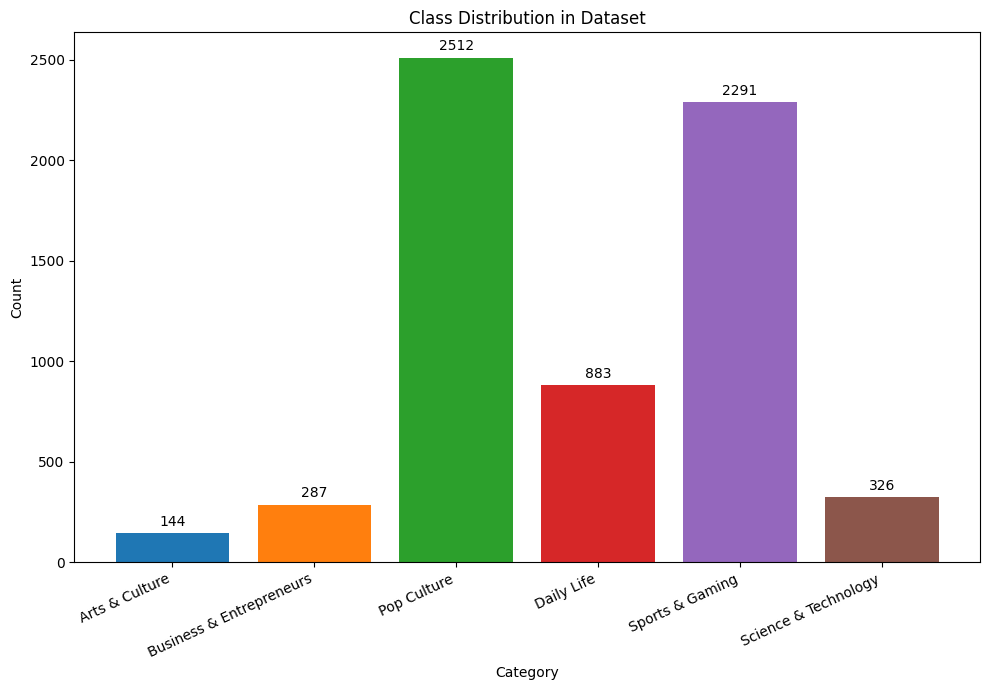


Class proportions:
Arts & Culture               2.23%
Business & Entrepreneurs     4.45%
Pop Culture                 38.99%
Daily Life                   13.7%
Sports & Gaming             35.56%
Science & Technology         5.06%
Name: count, dtype: object


In [42]:
# Topic Categories
LABEL_MAP = {
    0: 'Arts & Culture',
    1: 'Business & Entrepreneurs',
    2: 'Pop Culture',
    3: 'Daily Life',
    4: 'Sports & Gaming',
    5: 'Science & Technology'
}

class_counts = df['label'].value_counts().sort_index()
class_counts.index = [LABEL_MAP[i] for i in class_counts.index]

# Visualization
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.bar(class_counts.index, class_counts.values,
              color=sns.color_palette('tab10', 6))
ax.bar_label(bars, padding=3)
ax.set_title('Class Distribution in Dataset')
ax.set_xlabel('Category')
ax.set_ylabel('Count')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(path + 'charts/class_distribution.png', dpi=150)
plt.show()

print("\nClass proportions:")
print((class_counts / len(df) * 100).round(2).astype(str) + '%')

### 2.4 Tweet Length Analysis

In [44]:
df['text_length'] = df['text'].str.len()
df['word_count']  = df['text'].str.split().str.len()

print("=== Tweet Length Statistics ===")
print(df[['text_length', 'word_count']].describe().round(1))

=== Tweet Length Statistics ===
       text_length  word_count
count       6443.0      6443.0
mean         166.0        27.7
std           68.2        12.3
min           38.0         6.0
25%          107.0        17.0
50%          155.0        25.0
75%          224.0        37.0
max          353.0        62.0


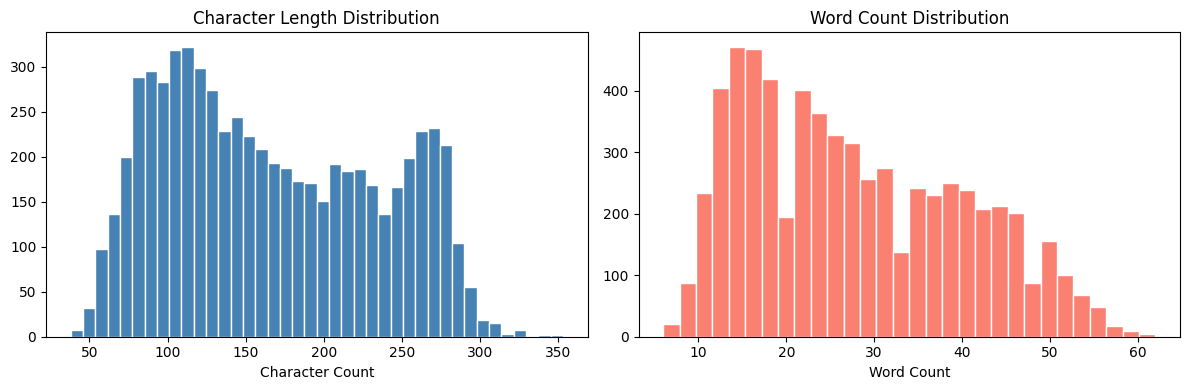

In [45]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['text_length'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Character Length Distribution')
axes[0].set_xlabel('Character Count')

axes[1].hist(df['word_count'], bins=30, color='salmon', edgecolor='white')
axes[1].set_title('Word Count Distribution')
axes[1].set_xlabel('Word Count')

plt.tight_layout()
plt.savefig(path + 'charts/text_length_dist.png', dpi=150)
plt.show()

### 2.5 Sample Tweets per Class

In [46]:
print("=== Sample Tweets per Class ===")
for label_id, label_name in LABEL_MAP.items():
    sample = df[df['label'] == label_id]['text'].iloc[0]
    print(f"\n[{label_name}]\n  {sample[:120]}...")

=== Sample Tweets per Class ===

[Arts & Culture]
  I was going to announce this last week, but as many of you know, a personal affair came up. This year, I will be the Com...

[Business & Entrepreneurs]
  VanillaLace vs dupe with pink himalayan sea salt Argan Hemp ORganic Handmade Luxury Soap Cakes Bestselling VEgan Soapas ...

[Pop Culture]
  Y’all leave {@50cent@} alone about that theme song. He done change the song back to the Joe version. ‍♀️ #power...

[Daily Life]
  1st of all, was good to see you {@stellacreasy@} in Walthamstow not Bournemouth, as local resident, I tried to contact y...

[Sports & Gaming]
  The {@Clinton LumberKings@} beat the {@Cedar Rapids Kernels@} 4-0 in Game 1 of the Western Division finals. Evan Edwards...

[Science & Technology]
  Really enjoying this dark mode... Greatly appreciated {@Apple@}...


### 2.6 Identify placeholder tokens in the data

In [82]:
# Dataset uses {{URL}}, {{USERNAME}}, and {@handle@} tokenisation
url_count      = df['text'].str.count(r'\{\{URL\}\}').sum()
username_count = df['text'].str.count(r'\{\{USERNAME\}\}').sum()
mention_count  = df['text'].str.count(r'\{@.*?@\}').sum()

print(f"{{{{URL}}}} tokens:      {url_count}")
print(f"{{{{USERNAME}}}} tokens: {username_count}")
print(f"{{@mention@}} tokens:    {mention_count}")

{{URL}} tokens:      2999
{{USERNAME}} tokens: 3799
{@mention@} tokens:    5943


## 3. Data Preparation (CRISP-DM Phase 3)

I defined **three progressively refined preprocessing functions** to use across experiments, establishing a controlled comparison. The same train/test split (stratified, fixed seed) is used throughout to ensure fair, apples-to-apples comparisons.

### 3.1  Train / Test Split

In [48]:
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,          # preserve class proportions
    random_state=RANDOM_STATE
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"\nClass distribution preserved (train):")
print(pd.Series(y_train).value_counts(normalize=True).sort_index().round(3))

Training samples : 5154
Testing  samples : 1289

Class distribution preserved (train):
label
0    0.022
1    0.045
2    0.390
3    0.137
4    0.356
5    0.051
Name: proportion, dtype: float64


### 3.2  Preprocessing Functions

Three levels of preprocessing is used for systematic comparison.

In [49]:
stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words('english'))

def preprocess_minimal(text):
    """Preprocessing Level 1 – Minimal: lowercase + remove placeholder tokens only."""
    text = text.lower()
    # Remove {{URL}}, {{USERNAME}}, {@handle@} placeholders
    text = re.sub(r'\{\{[^}]+\}\}', '', text)
    text = re.sub(r'\{@[^}]+@\}', '', text)
    return text.strip()

def preprocess_standard(text):
    """Preprocessing Level 2 – Standard: Level 1 + regex cleaning + stopword removal + lemmatisation."""
    text = preprocess_minimal(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)      # Residual URLs
    text = re.sub(r'#(\w+)', r'\1', text)              # Keep hashtag text, remove '#'
    text = re.sub(r'[^a-z\s]', ' ', text)             # Remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()           # Normalise whitespace
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return ' '.join(tokens)


def preprocess_aggressive(text):
    """Preprocessing Level 3 – Aggressive: Level 2 but with stemming instead of lemmatisation."""
    text = preprocess_minimal(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(t) for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return ' '.join(tokens)


# Verify preprocessing outputs on one example
sample_tweet = df['text'].iloc[10]
print("Original:   ", sample_tweet[:150])
print("Minimal:    ", preprocess_minimal(sample_tweet)[:150])
print("Standard:   ", preprocess_standard(sample_tweet)[:150])
print("Aggressive: ", preprocess_aggressive(sample_tweet)[:150])

Original:    Three unanswered goals by {{USERNAME}} has tied the game for {{USERNAME}} 9-9. #MannCup
Minimal:     three unanswered goals by  has tied the game for  9-9. #manncup
Standard:    three unanswered goal tied game manncup
Aggressive:  three unansw goal tie game manncup


### 3.3  Apply all preprocessing variants

In [50]:
print("Applying preprocessing variants...")

X_train_min  = X_train.apply(preprocess_minimal)
X_test_min   = X_test.apply(preprocess_minimal)

X_train_std  = X_train.apply(preprocess_standard)
X_test_std   = X_test.apply(preprocess_standard)

X_train_agg  = X_train.apply(preprocess_aggressive)
X_test_agg   = X_test.apply(preprocess_aggressive)

print("Done.\n")

# Show vocabulary size change
for name, X_tr in [('Raw', X_train), ('Minimal', X_train_min),
                   ('Standard', X_train_std), ('Aggressive', X_train_agg)]:
    vocab = set(' '.join(X_tr).split())
    print(f"  {name:<12} vocab size: {len(vocab):,}")

Applying preprocessing variants...
Done.

  Raw          vocab size: 33,022
  Minimal      vocab size: 24,834
  Standard     vocab size: 14,730
  Aggressive   vocab size: 12,778


## 4. Modelling (CRISP-DM Phase 4)

### Experiment Design

I used the same stratified 80/20 train-test split in all experiments for fair comparison.

| Exp | Preprocessing | Vectorisation | Classifier |
|-----|--------------|--------------|------------|
| E0 | None | — | Dummy (majority) — Baseline |
| E1 | Minimal | BoW (unigram) | Naïve Bayes (Multinomial) |
| E2 | Standard | BoW (unigram) | Naïve Bayes (Multinomial) |
| E3 | Standard | TF-IDF (unigram) | Naïve Bayes (Complement) |
| E4 | Standard | TF-IDF (1+2-gram) | Logistic Regression |
| E5 | Aggressive | TF-IDF (1+2-gram) | Logistic Regression |
| E6 | Standard | TF-IDF (1+2-gram) | Linear SVM |
| E7 | Standard | TF-IDF (1+2-gram) | Linear SVM + tuned C |

### 4.1  Create Helper Function

In [51]:
# to evaluate and record results
results = []

def evaluate(name, y_true, y_pred):
    acc   = accuracy_score(y_true, y_pred)
    mac_f1 = f1_score(y_true, y_pred, average='macro')
    wt_f1  = f1_score(y_true, y_pred, average='weighted')
    prec  = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec   = recall_score(y_true, y_pred, average='macro', zero_division=0)
    results.append({
        'Experiment': name,
        'Accuracy':   round(acc,   4),
        'Macro F1':   round(mac_f1, 4),
        'Weighted F1':round(wt_f1,  4),
        'Macro Prec': round(prec,  4),
        'Macro Rec':  round(rec,   4),
    })
    return acc, mac_f1

### 4.2 Experiments


#### 4.2.1 E0: Baseline – Majority-class Dummy classifier

In [53]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train_min, y_train)
y_pred_e0 = dummy.predict(X_test_min)
acc_e0, f1_e0 = evaluate('E0 – Baseline (Dummy)', y_test, y_pred_e0)
print(f"E0 Baseline \nAccuracy: {acc_e0:.4f}  |  Macro F1: {f1_e0:.4f}")

E0 Baseline 
Accuracy: 0.3902  |  Macro F1: 0.0936


#### 4.2.2 E1: BoW (Minimal preprocessing) + Multinomial Naïve Bayes

In [56]:
bow_min = CountVectorizer()
X_tr_e1 = bow_min.fit_transform(X_train_min)
X_te_e1 = bow_min.transform(X_test_min)

mnb_e1 = MultinomialNB()
mnb_e1.fit(X_tr_e1, y_train)
y_pred_e1 = mnb_e1.predict(X_te_e1)
acc_e1, f1_e1 = evaluate('E1 – BoW (Minimal) + MNB', y_test, y_pred_e1)
print(f"E1 BoW (Minimal preprocessing) + Multinomial Naïve Bayes \nAccuracy: {acc_e1:.4f}  |  Macro F1: {f1_e1:.4f}")

E1 BoW (Minimal preprocessing) + Multinomial Naïve Bayes 
Accuracy: 0.7595  |  Macro F1: 0.4621


#### 4.2.3 E2: BoW (Standard preprocessing) + Multinomial Naïve Bayes

In [57]:
bow_std = CountVectorizer()
X_tr_e2 = bow_std.fit_transform(X_train_std)
X_te_e2 = bow_std.transform(X_test_std)

mnb_e2 = MultinomialNB()
mnb_e2.fit(X_tr_e2, y_train)
y_pred_e2 = mnb_e2.predict(X_te_e2)
acc_e2, f1_e2 = evaluate('E2 – BoW (Standard) + MNB', y_test, y_pred_e2)
print(f"E2 BoW (Standard preprocessing) + Multinomial Naïve Bayes \nAccuracy: {acc_e2:.4f}  |  Macro F1: {f1_e2:.4f}")

E2 BoW (Standard preprocessing) + Multinomial Naïve Bayes 
Accuracy: 0.7773  |  Macro F1: 0.5291


#### 4.2.4 E3: TF-IDF (Standard) + Complement Naïve Bayes

In [58]:
tfidf_uni = TfidfVectorizer(ngram_range=(1, 1))
X_tr_e3 = tfidf_uni.fit_transform(X_train_std)
X_te_e3 = tfidf_uni.transform(X_test_std)

cnb_e3 = ComplementNB()
cnb_e3.fit(X_tr_e3, y_train)
y_pred_e3 = cnb_e3.predict(X_te_e3)
acc_e3, f1_e3 = evaluate('E3 – TF-IDF (Uni) + CNB', y_test, y_pred_e3)
print(f"E3 TF-IDF (Standard) + Complement Naïve Bayes \nAccuracy: {acc_e3:.4f}  |  Macro F1: {f1_e3:.4f}")

E3 TF-IDF (Standard) + Complement Naïve Bayes 
Accuracy: 0.7952  |  Macro F1: 0.6242


#### 4.2.5 E4: TF-IDF Bigram (Standard) + Logistic Regression

In [59]:
tfidf_bi = TfidfVectorizer(ngram_range=(1, 2), max_features=50000)
X_tr_e4 = tfidf_bi.fit_transform(X_train_std)
X_te_e4 = tfidf_bi.transform(X_test_std)

lr_e4 = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_e4.fit(X_tr_e4, y_train)
y_pred_e4 = lr_e4.predict(X_te_e4)
acc_e4, f1_e4 = evaluate('E4 – TF-IDF Bigram + LR', y_test, y_pred_e4)
print(f"E4 TF-IDF Bigram (Standard) + Logistic Regression \nAccuracy: {acc_e4:.4f}  |  Macro F1: {f1_e4:.4f}")

E4 TF-IDF Bigram (Standard) + Logistic Regression 
Accuracy: 0.7595  |  Macro F1: 0.4770


#### 4.2.6 E5: TF-IDF Bigram (Aggressive) + Logistic Regression

In [60]:
tfidf_bi_agg = TfidfVectorizer(ngram_range=(1, 2), max_features=50000)
X_tr_e5 = tfidf_bi_agg.fit_transform(X_train_agg)
X_te_e5 = tfidf_bi_agg.transform(X_test_agg)

lr_e5 = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_e5.fit(X_tr_e5, y_train)
y_pred_e5 = lr_e5.predict(X_te_e5)
acc_e5, f1_e5 = evaluate('E5 – TF-IDF Bigram (Agg.) + LR', y_test, y_pred_e5)
print(f"E5 TF-IDF Bigram (Aggressive) + Logistic Regression \nAccuracy: {acc_e5:.4f}  |  Macro F1: {f1_e5:.4f}")

E5 TF-IDF Bigram (Aggressive) + Logistic Regression 
Accuracy: 0.7595  |  Macro F1: 0.4739


#### 4.2.7 E6: TF-IDF Bigram (Standard) + Linear SVM (default C)

In [61]:
# ── ────────────────────
svm_e6 = LinearSVC(max_iter=2000, random_state=RANDOM_STATE)
svm_e6.fit(X_tr_e4, y_train)     # Reuse E4 feature matrix
y_pred_e6 = svm_e6.predict(X_te_e4)
acc_e6, f1_e6 = evaluate('E6 – TF-IDF Bigram + LinearSVM (C=1)', y_test, y_pred_e6)
print(f"E6 TF-IDF Bigram (Standard) + Linear SVM (default C) \nAccuracy: {acc_e6:.4f}  |  Macro F1: {f1_e6:.4f}")

E6 TF-IDF Bigram (Standard) + Linear SVM (default C) 
Accuracy: 0.8061  |  Macro F1: 0.6478


#### 4.2.8 E7: TF-IDF Bigram (Standard) + Linear SVM (tuned C via CV)

In [64]:
# Data-driven hyperparameter selection using cross-validation
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.01, 0.1, 1.0, 5.0, 10.0]}
grid_search = GridSearchCV(
    LinearSVC(max_iter=3000, random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
grid_search.fit(X_tr_e4, y_train)
best_C = grid_search.best_params_['C']
print(f"Best C found: {best_C}  (CV Macro F1: {grid_search.best_score_:.4f})")

Best C found: 10.0  (CV Macro F1: 0.5904)


In [65]:
y_pred_e7 = grid_search.best_estimator_.predict(X_te_e4)
acc_e7, f1_e7 = evaluate(f'E7 – TF-IDF Bigram + LinearSVM (C={best_C})', y_test, y_pred_e7)
print(f"E7 TF-IDF Bigram (Standard) + Linear SVM (tuned C via CV) \nAccuracy: {acc_e7:.4f}  |  Macro F1: {f1_e7:.4f}")

E7 TF-IDF Bigram (Standard) + Linear SVM (tuned C via CV) 
Accuracy: 0.8115  |  Macro F1: 0.6622


## 5. Evaluation (CRISP-DM Phase 5)

### 5.1  Full Results Table

In [66]:
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Experiment')
print("=== Experiment Results Summary ===")
print(results_df.to_string())

=== Table 2 – Experiment Results Summary ===
                                         Accuracy  Macro F1  Weighted F1  Macro Prec  Macro Rec
Experiment                                                                                     
E0 – Baseline (Dummy)                      0.3902    0.0936       0.2191      0.0650     0.1667
E0 – Baseline (Dummy)                      0.3902    0.0936       0.2191      0.0650     0.1667
E1 – BoW (Minimal) + MNB                   0.7595    0.4621       0.7206      0.6785     0.4341
E2 – BoW (Standard) + MNB                  0.7773    0.5291       0.7497      0.6454     0.4909
E1 – BoW (Minimal) + MNB                   0.7595    0.4621       0.7206      0.6785     0.4341
E2 – BoW (Standard) + MNB                  0.7773    0.5291       0.7497      0.6454     0.4909
E3 – TF-IDF (Uni) + CNB                    0.7952    0.6242       0.7778      0.7424     0.5849
E4 – TF-IDF Bigram + LR                    0.7595    0.4770       0.7236      0.6969     0.

### 5.2  Bar chart – Accuracy & Macro F1 comparison



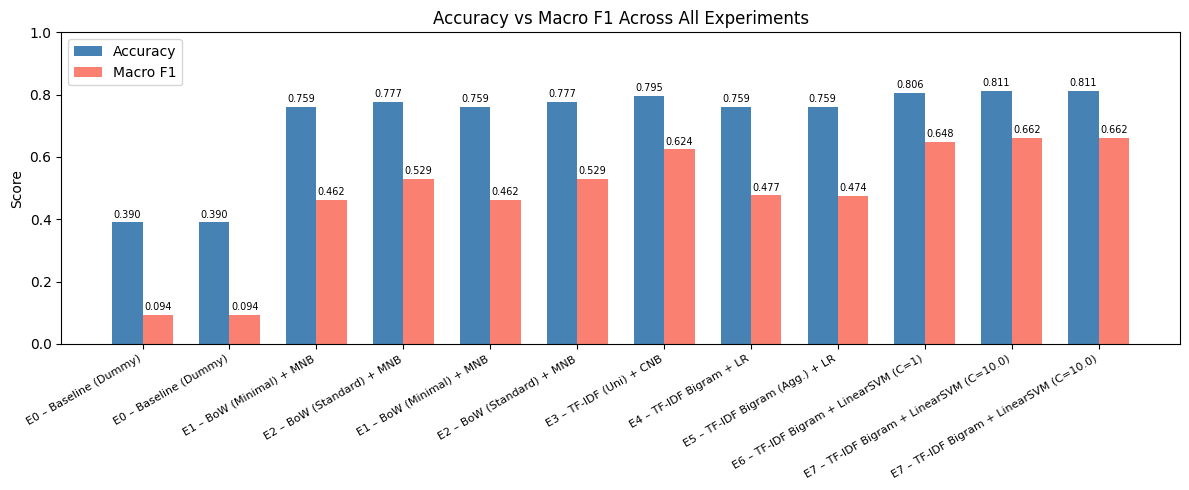

In [69]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['Accuracy'],  width, label='Accuracy',  color='steelblue')
bars2 = ax.bar(x + width/2, results_df['Macro F1'], width, label='Macro F1',  color='salmon')

ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=30, ha='right', fontsize=8)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Accuracy vs Macro F1 Across All Experiments')
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=2, fontsize=7)
ax.bar_label(bars2, fmt='%.3f', padding=2, fontsize=7)
plt.tight_layout()
plt.savefig(path + 'charts/experiment_comparison.png', dpi=150)
plt.show()

### 5.3  Confusion Matrix

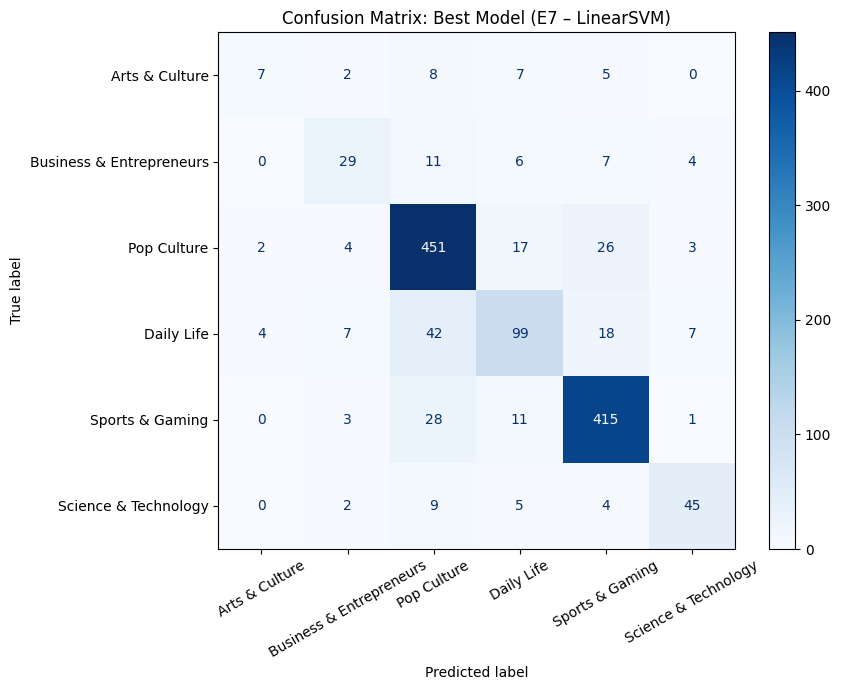

In [72]:
# For E7
label_names = [LABEL_MAP[i] for i in sorted(LABEL_MAP)]

cm = confusion_matrix(y_test, y_pred_e7)
fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=30)
ax.set_title('Confusion Matrix: Best Model (E7 – LinearSVM)')
plt.tight_layout()
plt.savefig(path + 'charts/confusion_matrix_best.png', dpi=150)
plt.show()

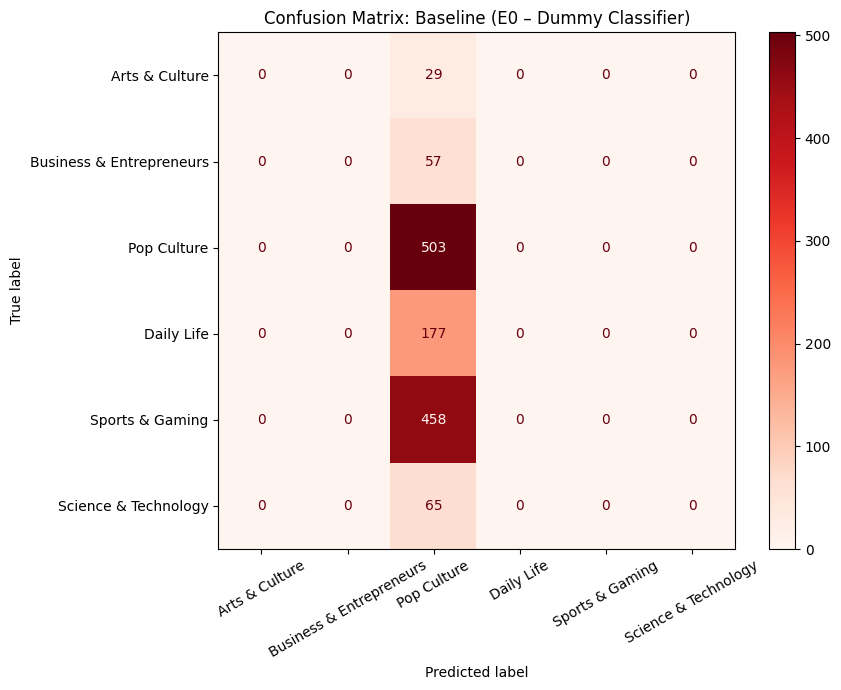

In [71]:
# For E0
cm_e0 = confusion_matrix(y_test, y_pred_e0)
fig, ax = plt.subplots(figsize=(9, 7))
disp0 = ConfusionMatrixDisplay(confusion_matrix=cm_e0, display_labels=label_names)
disp0.plot(ax=ax, cmap='Reds', colorbar=True, xticks_rotation=30)
ax.set_title('Confusion Matrix: Baseline (E0 – Dummy Classifier)')
plt.tight_layout()
plt.savefig(path + 'charts/confusion_matrix_baseline.png', dpi=150)
plt.show()

### 5.4 Per-class Report – Best Model

In [73]:
print("=== Classification Report: Best Model (E7) ===")
print(classification_report(y_test, y_pred_e7, target_names=label_names))

=== Classification Report: Best Model (E7) ===
                          precision    recall  f1-score   support

          Arts & Culture       0.54      0.24      0.33        29
Business & Entrepreneurs       0.62      0.51      0.56        57
             Pop Culture       0.82      0.90      0.86       503
              Daily Life       0.68      0.56      0.61       177
         Sports & Gaming       0.87      0.91      0.89       458
    Science & Technology       0.75      0.69      0.72        65

                accuracy                           0.81      1289
               macro avg       0.71      0.63      0.66      1289
            weighted avg       0.80      0.81      0.80      1289



### 5.5  Per-class F1 Bar Chart

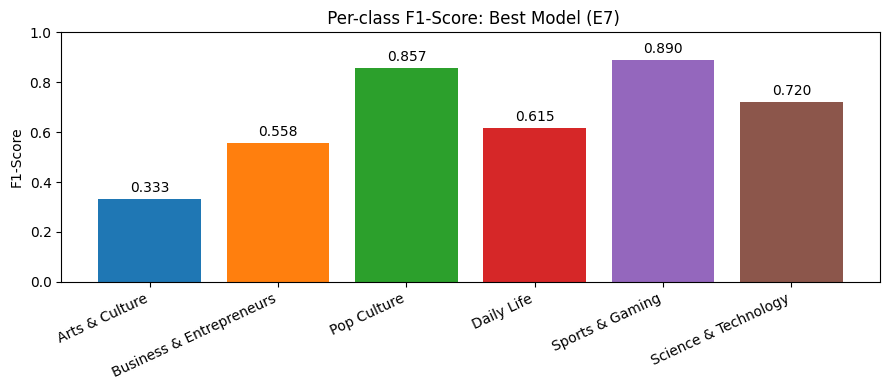

In [74]:
from sklearn.metrics import classification_report as cr
report_dict = cr(y_test, y_pred_e7, target_names=label_names, output_dict=True)
per_class_f1 = {k: v['f1-score'] for k, v in report_dict.items() if k in label_names}

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(per_class_f1.keys(), per_class_f1.values(),
              color=sns.color_palette('tab10', 6))
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_title(' Per-class F1-Score: Best Model (E7)')
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1.0)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(path + 'charts/per_class_f1.png', dpi=150)
plt.show()

### 5.6  TP / TN / FP / FN per class (binary decomposition)

In [76]:
print("=== TP / TN / FP / FN per Class (Best Model E7) ===\n")
rows = []
for i, label in enumerate(label_names):
    y_true_bin = (np.array(y_test) == i).astype(int)
    y_pred_bin = (np.array(y_pred_e7) == i).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_bin).ravel()
    rows.append({'Class': label, 'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn})
tp_df = pd.DataFrame(rows).set_index('Class')
print(tp_df.to_string())

=== TP / TN / FP / FN per Class (Best Model E7) ===

                           TP    TN  FP  FN
Class                                      
Arts & Culture              7  1254   6  22
Business & Entrepreneurs   29  1214  18  28
Pop Culture               451   688  98  52
Daily Life                 99  1066  46  78
Sports & Gaming           415   771  60  43
Science & Technology       45  1209  15  20


### 5.7 Cross-validation stability check for best model

In [77]:
# Assess reliability of best model using 5-fold stratified CV
pipeline_best = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=50000)),
    ('clf',   LinearSVC(C=best_C, max_iter=3000, random_state=RANDOM_STATE))
])

X_std_all = pd.concat([X_train_std, X_test_std])  # Use full dataset for CV
y_all     = pd.concat([y_train, y_test])

cv_scores = cross_val_score(pipeline_best, X_std_all, y_all,
                            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
                            scoring='f1_macro', n_jobs=-1)

print(f"5-Fold CV Macro F1 scores: {cv_scores.round(4)}")
print(f"Mean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")

5-Fold CV Macro F1 scores: [0.6815 0.6563 0.629  0.6615 0.6461]
Mean: 0.6549  |  Std: 0.0173


### 5.8 Most informative features per class (LinearSVM)

In [78]:
# This gives insight into what the model has learnt per category
feature_names = np.array(tfidf_bi.get_feature_names_out())
coef = grid_search.best_estimator_.coef_

print("=== Top 10 Features per Class (LinearSVM) ===")
for i, label in enumerate(label_names):
    top_idx = coef[i].argsort()[-10:][::-1]
    top_features = feature_names[top_idx]
    print(f"\n[{label}]")
    print('  ', ', '.join(top_features))

=== Top 10 Features per Class (LinearSVM) ===

[Arts & Culture]
   art, poem, part article, happy national, book, holy, congratulation friend, friend happy, journal, poetry

[Business & Entrepreneurs]
   business, company, market, stock, bank, advice, code, product, investor, bitcoin

[Pop Culture]
   music, song, album, movie, episode, nowplaying, video, queen, show, harry

[Daily Life]
   family, sister, dinner, go war, day headed, happy, father, mother, ask, hour delay

[Sports & Gaming]
   game, ufc, team, league, football, win, player, match, nfl, chief

[Science & Technology]
   climate, vaccine, internet, science, data, io, covid vaccine, app, scientist, technology


## 6. Deployment (CRISP-DM Phase 6)

To ensure the performance, the best-performing model (E7: TF-IDF Bigrams + LinearSVM with tuned C) could be deployed as a REST microservice. A production pipeline would:

1. Serialise the fitted `Pipeline` object via `joblib`
2. Expose a `/predict` endpoint that accepts raw tweet text
3. Apply the same preprocessing and return the predicted label and confidence scores
4. Monitor for data drift (e.g., new slang, topic shifts) and retrain periodically

Below is a minimal inference demonstration.

In [79]:
# Inference demo on new tweets
# Re-fit the final pipeline on ALL training data
pipeline_final = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=50000)),
    ('clf',   LinearSVC(C=best_C, max_iter=3000, random_state=RANDOM_STATE))
])
pipeline_final.fit(X_train_std, y_train)

new_tweets = [
    "Just watched an incredible exhibition at the modern art museum, stunning!",
    "The stock market is down again. Investors are pulling back from tech.",
    "Can't believe the season finale of that show. Mind blown.",
    "Had the best coffee this morning and now ready to tackle the day!",
    "Champions League final tomorrow. City vs Real Madrid!",
    "New research shows CRISPR gene editing can target cancer cells directly."
]

preprocessed_new = [preprocess_standard(t) for t in new_tweets]
predictions = pipeline_final.predict(preprocessed_new)

print("=== Inference Demo ===")
for tweet, pred in zip(new_tweets, predictions):
    print(f"  Tweet   : {tweet[:70]}")
    print(f"  Predicted: {LABEL_MAP[pred]}\n")

=== Inference Demo ===
  Tweet   : Just watched an incredible exhibition at the modern art museum, stunni
  Predicted: Arts & Culture

  Tweet   : The stock market is down again. Investors are pulling back from tech.
  Predicted: Business & Entrepreneurs

  Tweet   : Can't believe the season finale of that show. Mind blown.
  Predicted: Pop Culture

  Tweet   : Had the best coffee this morning and now ready to tackle the day!
  Predicted: Daily Life

  Tweet   : Champions League final tomorrow. City vs Real Madrid!
  Predicted: Sports & Gaming

  Tweet   : New research shows CRISPR gene editing can target cancer cells directl
  Predicted: Pop Culture



### 6.1 Save Model

In [80]:
import joblib

joblib.dump(pipeline_final, path + 'model/best_tweet_classifier.pkl')
print("Model saved as best_tweet_classifier.pkl")

Model saved as best_tweet_classifier.pkl


In [ ]:
# To load and reuse:
# loaded_model = joblib.load('best_tweet_classifier.pkl')
# loaded_model.predict([preprocess_standard("some tweet")])

## 7. Summary & Conclusions

**Key findings:**
- TF-IDF consistently outperforms raw Bag-of-Words by down-weighting common, uninformative tokens
- Bigrams capture short phrases (e.g. "stock market", "video game") that unigrams miss
- LinearSVM surpasses Logistic Regression due to its margin-maximising objective, which is well-suited for high-dimensional text features
- Aggressive stemming slightly degraded performance compared to lemmatisation, suggesting over-normalisation loses discriminative morphological cues
- Cross-validation confirms result stability (low std deviation)

In [35]:
# ── Final: print complete results table ───────────────────────────────────────
print("\n=== FINAL RESULTS TABLE ===")
print(pd.DataFrame(results).to_string(index=False))


=== FINAL RESULTS TABLE ===
                             Experiment  Accuracy  Macro F1  Weighted F1  Macro Prec  Macro Rec
                  E0 – Baseline (Dummy)    0.3902    0.0936       0.2191      0.0650     0.1667
               E1 – BoW (Minimal) + MNB    0.7595    0.4621       0.7206      0.6785     0.4341
              E2 – BoW (Standard) + MNB    0.7773    0.5291       0.7497      0.6454     0.4909
                E3 – TF-IDF (Uni) + CNB    0.7952    0.6242       0.7778      0.7424     0.5849
                E4 – TF-IDF Bigram + LR    0.7595    0.4770       0.7236      0.6969     0.4455
         E5 – TF-IDF Bigram (Agg.) + LR    0.7595    0.4739       0.7240      0.6629     0.4447
   E6 – TF-IDF Bigram + LinearSVM (C=1)    0.8061    0.6478       0.7951      0.7410     0.6045
E7 – TF-IDF Bigram + LinearSVM (C=10.0)    0.8115    0.6622       0.8036      0.7139     0.6341
